# Healthcare Patient Analytics Exploration

## Project Overview

This project explores healthcare admission data using Python to identify trends in patient demographics, hospital operations, length of stay, and healthcare outcomes.

In [326]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

## Data Inspection

### 1. Load Dataset

In [327]:
df = pd.read_csv("../data/healthcare_dataset.csv")

df.head()

,Patient_ID,Admission_Date,Discharge_Date,Age,Age_Group,Gender,Condition_Type,Department,Severity_Score,Length_of_Stay,Insurance_Type,Discharge_Status,Readmission_Within_30_Days,Clinical_Notes
0,1,2023-04-17,2023-04-28,51,41-60,Other,Heart Failure,ICU,6,11,Private,Home,No,Heart Failure managed during admission; status...
1,2,2023-04-13,2023-04-16,71,61+,Male,Asthma,Pediatrics,2,3,Medicare,Home,No,Clinical course involved Asthma; patient was h...
2,3,2023-03-29,2023-04-12,82,61+,Other,Heart Failure,ICU,9,14,Medicare,Expired,No,Patient case: Heart Failure. Final status: Exp...
3,4,2023-11-05,2023-11-14,23,13-24,Male,Appendicitis,Surgery,6,9,Private,Home,No,Patient treated for Appendicitis. Discharge ou...
4,5,2023-10-21,2023-10-29,1,0-12,Male,Asthma,Pediatrics,4,8,Private,Home,No,Patient case: Asthma. Final status: Home.


### 2. Dataset Overview

In [328]:
df.shape

(500, 14)

In [329]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Patient_ID                  500 non-null    int64
 1   Admission_Date              500 non-null    str  
 2   Discharge_Date              500 non-null    str  
 3   Age                         500 non-null    int64
 4   Age_Group                   500 non-null    str  
 5   Gender                      500 non-null    str  
 6   Condition_Type              500 non-null    str  
 7   Department                  500 non-null    str  
 8   Severity_Score              500 non-null    int64
 9   Length_of_Stay              500 non-null    int64
 10  Insurance_Type              500 non-null    str  
 11  Discharge_Status            500 non-null    str  
 12  Readmission_Within_30_Days  500 non-null    str  
 13  Clinical_Notes              500 non-null    str  
dtypes: int64(4), str(10)


### 3. Data Quality Checks

In [330]:
df.isnull().sum()

Patient_ID                    0
Admission_Date                0
Discharge_Date                0
Age                           0
Age_Group                     0
Gender                        0
Condition_Type                0
Department                    0
Severity_Score                0
Length_of_Stay                0
Insurance_Type                0
Discharge_Status              0
Readmission_Within_30_Days    0
Clinical_Notes                0
dtype: int64

In [331]:
df.duplicated().sum()

np.int64(0)

In [332]:
df.describe()

,Patient_ID,Age,Severity_Score,Length_of_Stay
count,500.000000,500.000000,500.000000,500.000000
mean,250.500000,44.864000,5.234000,8.802000
std,144.481833,27.434044,2.110011,2.795429
min,1.000000,0.000000,1.000000,2.000000
25%,125.750000,22.000000,4.000000,7.000000
50%,250.500000,45.000000,5.000000,9.000000
75%,375.250000,67.000000,7.000000,11.000000
max,500.000000,94.000000,10.000000,15.000000


In [333]:
df.nunique()

Patient_ID                    500
Admission_Date                269
Discharge_Date                286
Age                            95
Age_Group                       5
Gender                          3
Condition_Type                 10
Department                      9
Severity_Score                 10
Length_of_Stay                 14
Insurance_Type                  4
Discharge_Status                3
Readmission_Within_30_Days      2
Clinical_Notes                 86
dtype: int64

In [334]:
df["Department"].value_counts()

Department
ICU                 100
Geriatrics           59
Orthopedics          56
General Medicine     55
Pulmonology          53
Surgery              49
Obstetrics           47
Pediatrics           42
Endocrinology        39
Name: count, dtype: int64

In [335]:
df["Discharge_Status"].value_counts()

Discharge_Status
Home                    393
Transferred to Rehab     97
Expired                  10
Name: count, dtype: int64

In [336]:
df["Readmission_Within_30_Days"].value_counts()

Readmission_Within_30_Days
No     412
Yes     88
Name: count, dtype: int64

## Dataset Observations
- The dataset comprises 500 patient records with 14 variables covering demographics, clinical data, operations, and outcomes.
- Numeric variables include age, severity score, and length of stay.
- Date variables require conversion from string format into datetime format.
- Requires categorical frequency checks, with length of stay and readmission status serving as primary metrics.

## Data Cleaning

### 1. Convert Data Types

In [337]:
df["Admission_Date"] = pd.to_datetime(df["Admission_Date"])
df["Discharge_Date"] = pd.to_datetime(df["Discharge_Date"])

## Feature Engineering

### 1. Admission Month Field

In [338]:
df["Admission_Month"] = df["Admission_Date"].dt.month_name()

### 2. High Severity Field

In [339]:
df["High_Severity"] = df["Severity_Score"] >= 8

### 3. Long Stay Field

In [340]:
df["Long_Stay"] = df["Length_of_Stay"] > 7

### 4. Weekend Field

In [341]:
df["Weekend_Admission"] = df["Admission_Date"].dt.dayofweek >= 5

## Exploratory Analysis

### 1. Patient Demographics

Age Distribution

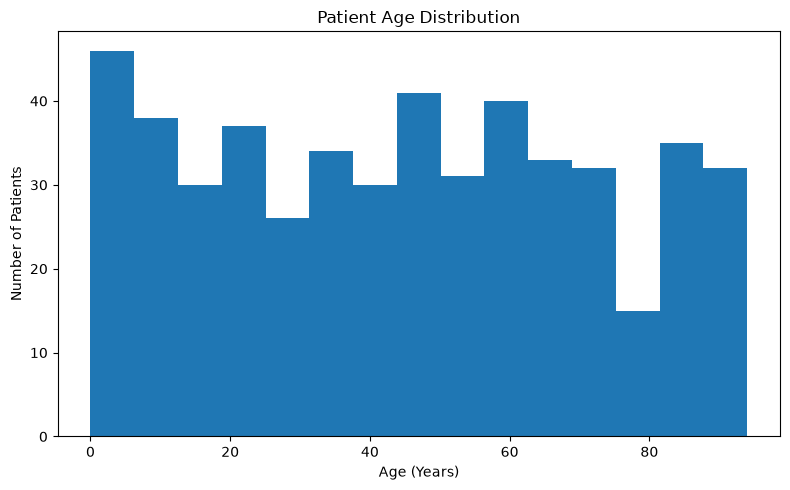

In [342]:
plt.figure(figsize=(8,5))

plt.hist(df["Age"], bins=15)

plt.title("Patient Age Distribution")
plt.xlabel("Age (Years)")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

Gender Distribution

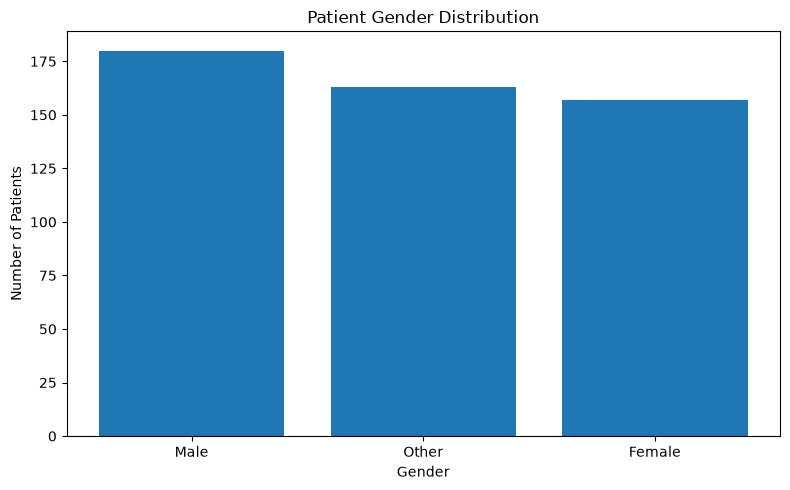

In [343]:
gender_counts = df["Gender"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(gender_counts.index, gender_counts.values)

plt.title("Patient Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

Age Groups

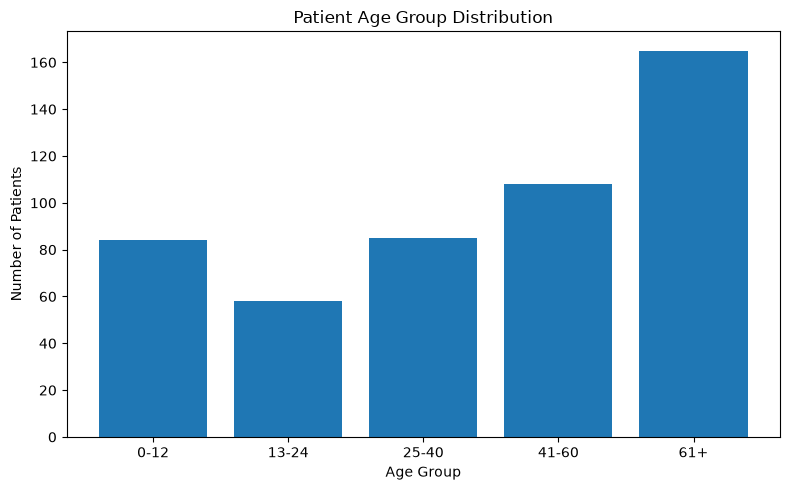

In [344]:
age_group_counts = df["Age_Group"].value_counts().sort_index(ascending=True)

plt.figure(figsize=(8,5))

plt.bar(age_group_counts.index, age_group_counts.values)

plt.title("Patient Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

### 2. Clinical Analysis

Most Common Conditions

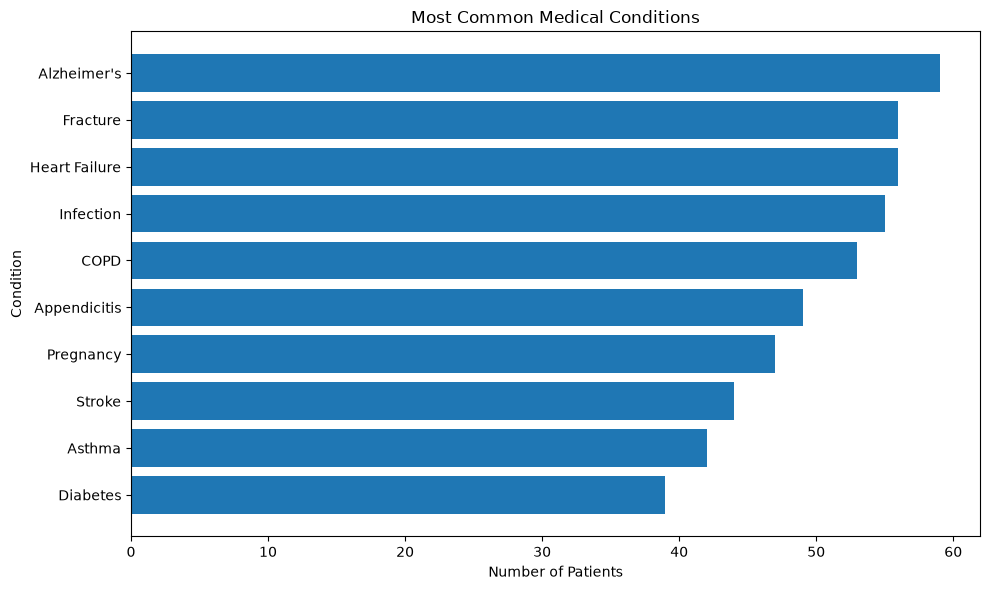

In [345]:
condition_type_counts = df["Condition_Type"].value_counts().sort_values(ascending=True)

plt.figure(figsize=(10,6))

plt.barh(condition_type_counts.index, condition_type_counts.values)

plt.title("Most Common Medical Conditions")
plt.xlabel("Number of Patients")
plt.ylabel("Condition")

plt.tight_layout()
plt.show()

Severity by Condition

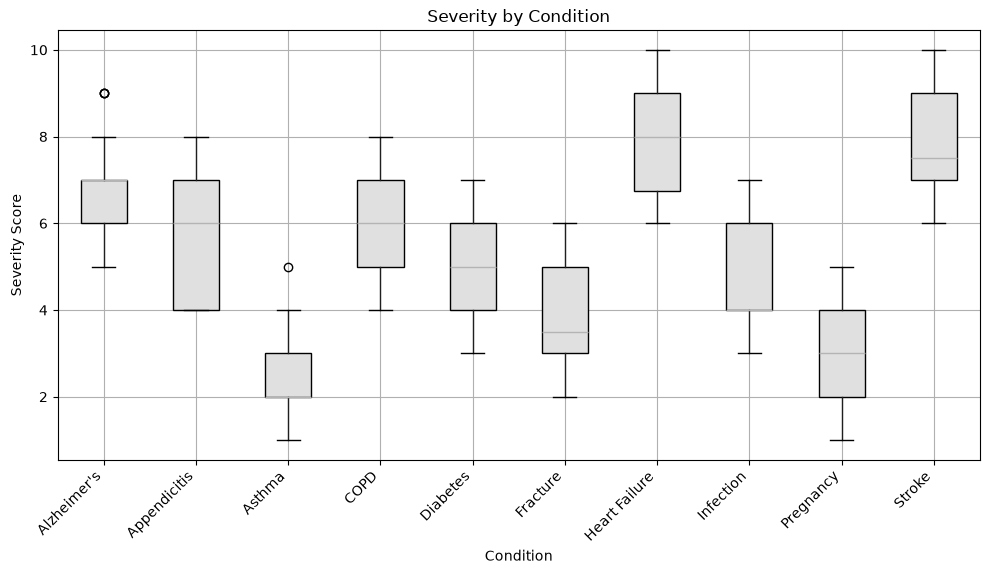

In [346]:
df.boxplot(column="Severity_Score", by="Condition_Type", figsize=(10, 6),
  patch_artist=True,
  boxprops=dict(facecolor='#e0e0e0', color='black')) 

plt.title("Severity by Condition")
plt.suptitle("") 
plt.xlabel("Condition")
plt.ylabel("Severity Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 3. Hospital Operations

LOS Distribution

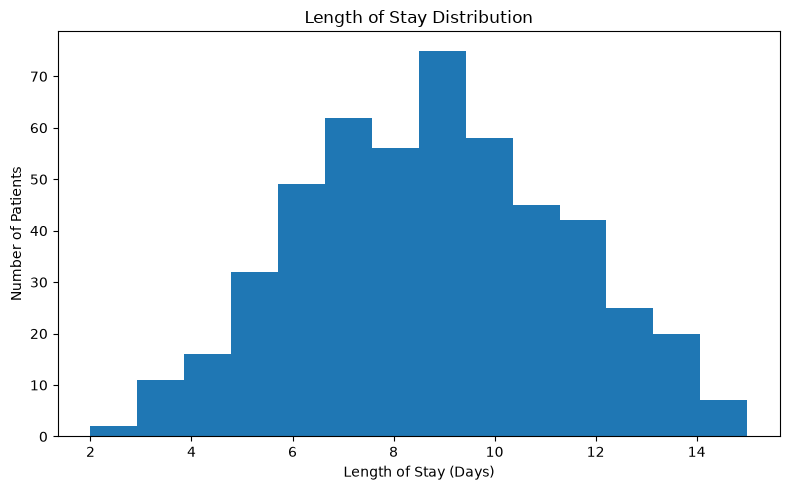

In [347]:
plt.figure(figsize=(8,5))

plt.hist(
    df["Length_of_Stay"],
    bins=14
)

plt.title("Length of Stay Distribution")
plt.xlabel("Length of Stay (Days)")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

Admissions by Month

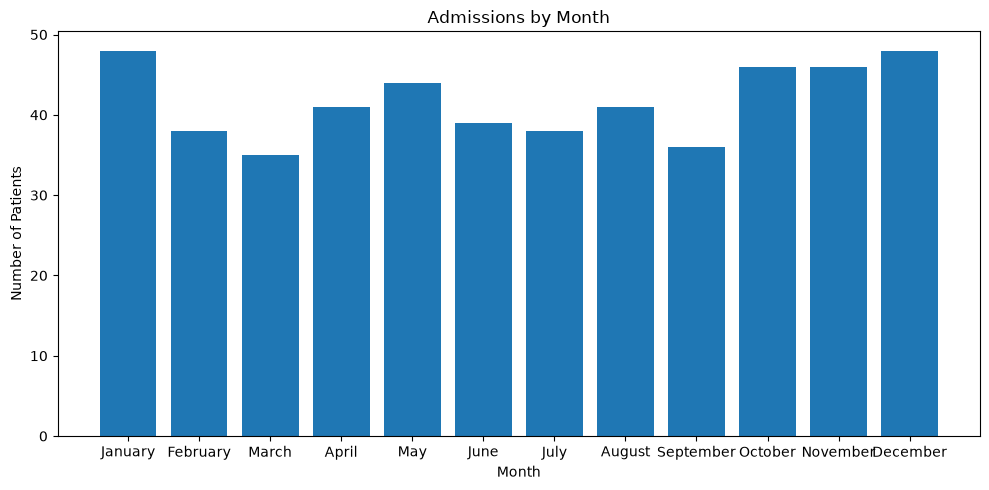

In [348]:
month_order = [
    "January", "February", "March", "April", "May", "June", 
    "July", "August", "September", "October", "November", "December"
]
df["Admission_Month"] = pd.Categorical(df["Admission_Month"], categories=month_order, ordered=True)

month_counts = df["Admission_Month"].value_counts().sort_index()

plt.figure(figsize=(10, 5))

plt.bar(month_counts.index, month_counts.values)

plt.title("Admissions by Month")
plt.xlabel("Month")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

Departments with Most Patients

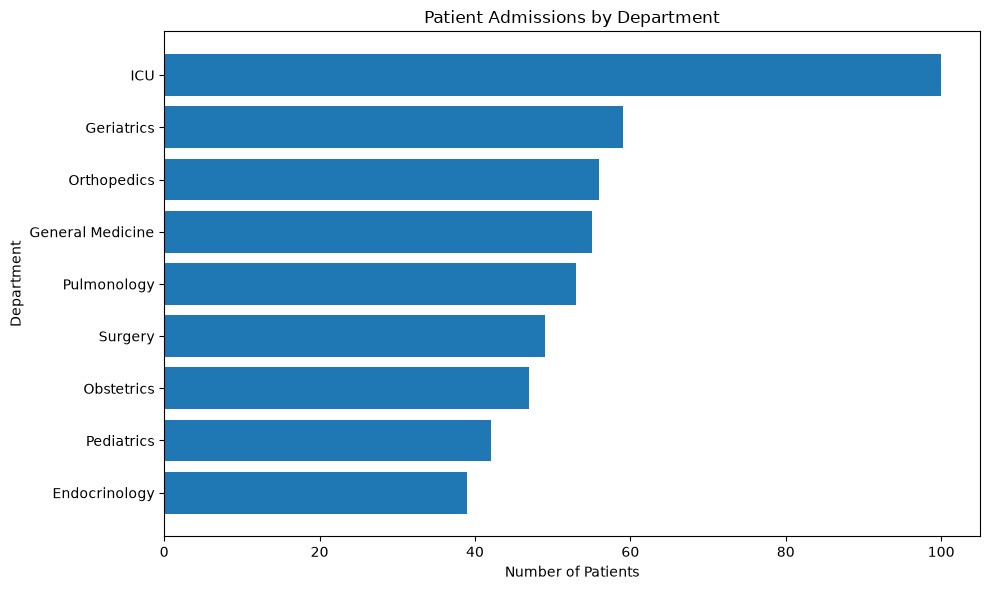

In [349]:
department_counts = df["Department"].value_counts().sort_values(ascending=True)

plt.figure(figsize=(10,6))

plt.barh(department_counts.index, department_counts.values)

plt.title("Patient Admissions by Department")
plt.xlabel("Number of Patients")
plt.ylabel("Department")

plt.tight_layout()
plt.show()

Average LOS by Department

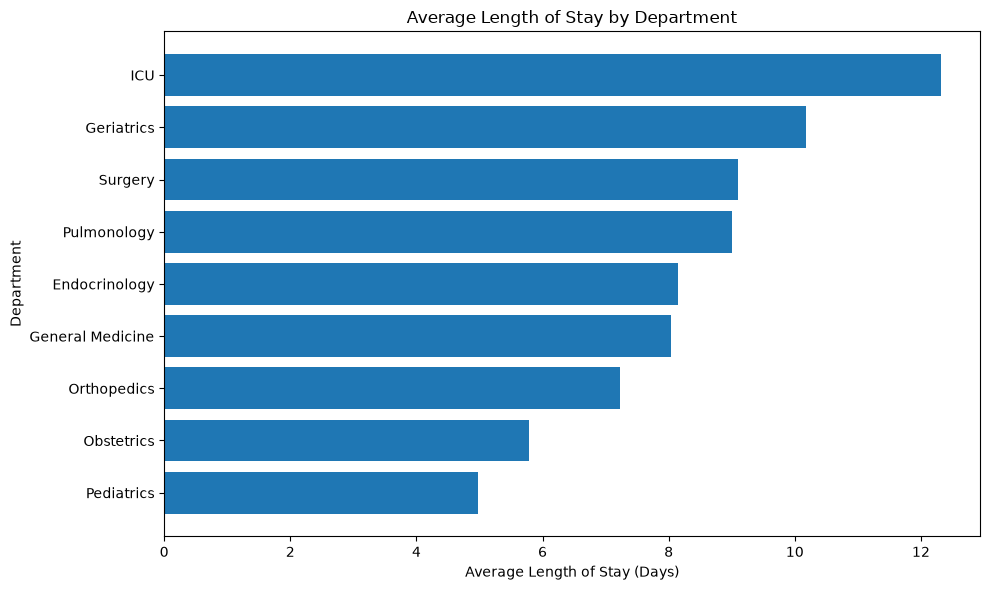

In [350]:
avg_los_department = (
    df.groupby("Department")["Length_of_Stay"]
      .mean()
      .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(avg_los_department.index, avg_los_department.values)

plt.title("Average Length of Stay by Department")
plt.xlabel("Average Length of Stay (Days)")
plt.ylabel("Department")

plt.tight_layout()
plt.show()

### 5. Readmissions

Readmission Rates

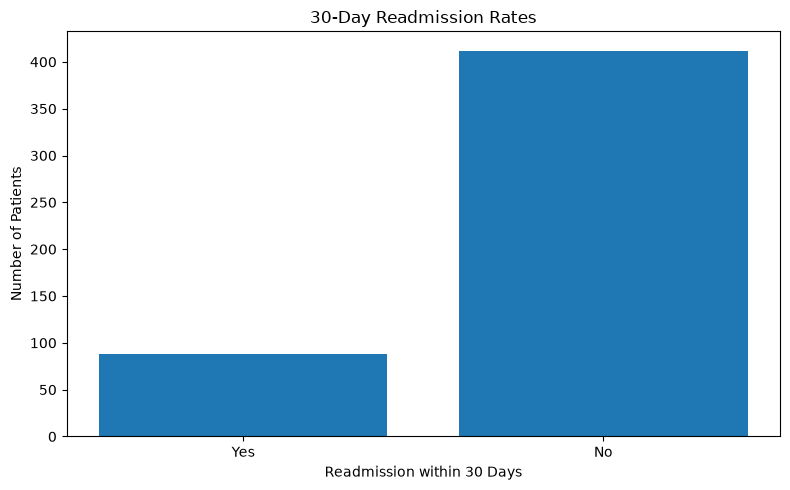

In [351]:
readmission_counts = df["Readmission_Within_30_Days"].value_counts().sort_index(ascending=False)

plt.figure(figsize=(8,5))

plt.bar(readmission_counts.index, readmission_counts.values)

plt.title("30-Day Readmission Rates")
plt.xlabel("Readmission within 30 Days")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

Readmissions by Severity

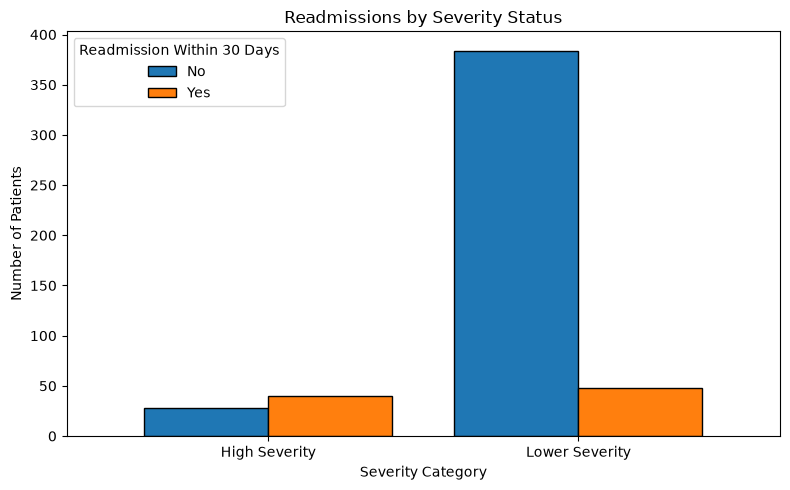

In [352]:
severity_counts = pd.crosstab(
    df["High_Severity"].map({
        True:"High Severity",
        False:"Lower Severity"
    }), 
    df["Readmission_Within_30_Days"]
)

severity_counts.plot(kind="bar", figsize=(8, 5), width=0.8, edgecolor="black")

plt.title("Readmissions by Severity Status")
plt.xlabel("Severity Category")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0) 

plt.legend(title="Readmission Within 30 Days")

plt.tight_layout()
plt.show()


### 6. Relationships

Severity vs LOS

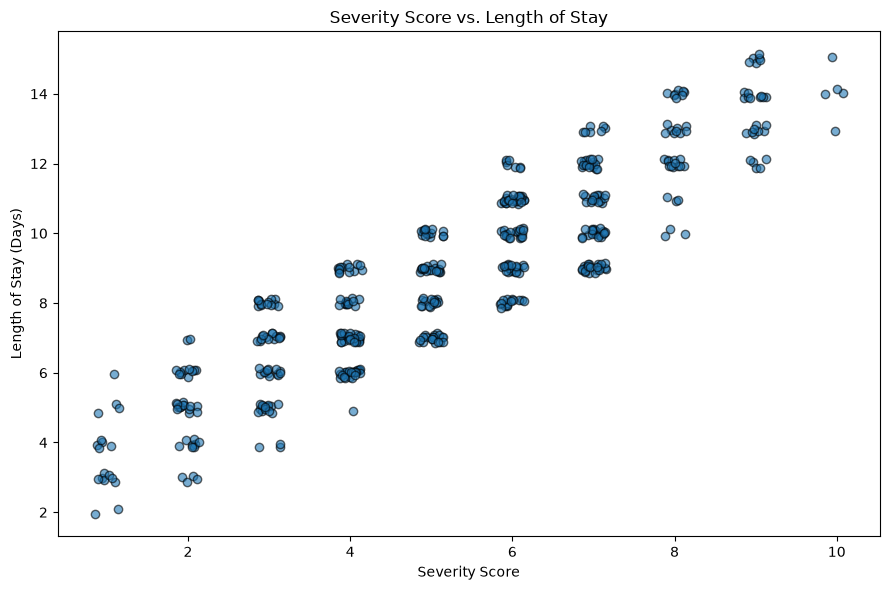

In [353]:
plt.figure(figsize=(9, 6))

jitter_x = df["Severity_Score"] + np.random.uniform(-0.15, 0.15, size=len(df))
jitter_y = df["Length_of_Stay"] + np.random.uniform(-0.15, 0.15, size=len(df))

plt.scatter(jitter_x, jitter_y, alpha=0.6, edgecolor="black")

plt.title("Severity Score vs. Length of Stay")
plt.xlabel("Severity Score")
plt.ylabel("Length of Stay (Days)")

plt.tight_layout()
plt.show()

## Business Insights